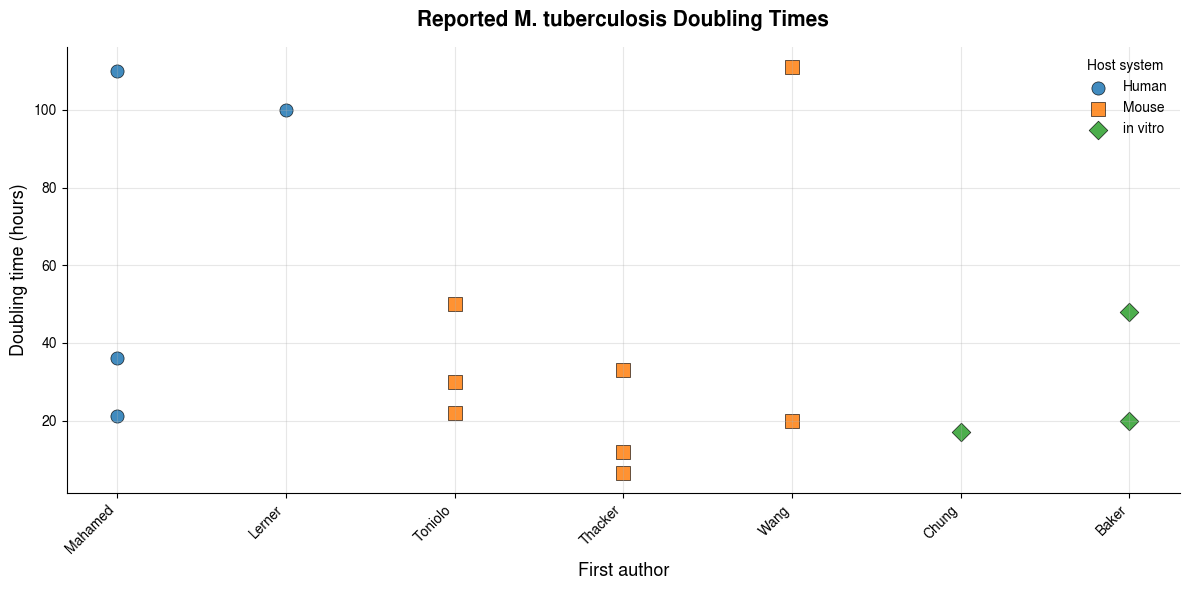

In [13]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
import numpy as np
# --- Style settings ---
rcParams["font.family"] = "Nimbus Sans" #"Helvetica"
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.grid"] = True
rcParams["grid.alpha"] = 0.3

# Data
data = [
    ("Chung", "Chung 2024 Nat Micro", 17, "in vitro"),
    ("Mahamed", "Mahamed 2017 eLife (live MDM)", 110, "Human"),
    ("Mahamed", "Mahamed 2017 eLife (dead MDM)", 21.2, "Human"),
    ("Mahamed", "Mahamed 2017 eLife (extracellular)", 36.1, "Human"),
    ("Toniolo", "Toniolo 2024 (WT intra)", 30, "Mouse"),
    ("Toniolo", "Toniolo 2024 (WT extra)", 22, "Mouse"),
    ("Toniolo", "Toniolo 2024 (ESX1 intra)", 50, "Mouse"),
    ("Lerner", "Lerner 2017 JCB", 100, "Human"),
    ("Thacker", "Thacker 2020 eLife (AT NS)", 12, "Mouse"),
    ("Thacker", "Thacker 2020 eLife (Mac NS)", 33, "Mouse"),
    ("Thacker", "Thacker 2020 eLife (AT/Mac DS)", 6.5, "Mouse"),
    ("Baker", "Baker 2014 Mol Micro (neutral)", 20, "in vitro"),
    ("Baker", "Baker 2014 Mol Micro (acidic, permissive)", 48, "in vitro"),
    ("Wang", "Wang 2019 eLife (acute)", 20, "Mouse"),
    ("Wang", "Wang 2019 eLife (chronic)", 111, "Mouse"),
    # ("Wang", "Wang 2019 eLife (ΔperM chronic)", 280, "Mouse"),
    # ("Gill", "Gill 2009 Nat Med (acute)", 24, "Mouse"),
    # ("Gill", "Gill 2009 Nat Med (chronic)", 100, "Mouse"),
    # ("Muñoz", "Muñoz 2005 Infect Immun (acute)", 24.6, "Mouse"),
    # ("Muñoz", "Muñoz 2005 Infect Immun (chronic)", 1676, "Mouse"),
]

df = pd.DataFrame(data, columns=["Author", "Paper", "DoublingTime_h", "Host"])

# Colors + markers
color_map = {"Human": "tab:blue", "Mouse": "tab:orange", "in vitro": "tab:green"}
marker_map = {"Human": "o", "Mouse": "s", "in vitro": "D"}

# Plot
plt.figure(figsize=(12, 6))
for host, subset in df.groupby("Host"):
    plt.scatter(
        subset["Author"],  # group by first author on x-axis
        subset["DoublingTime_h"],
        label=host,
        color=color_map.get(host, "gray"),
        marker=marker_map.get(host, "o"),
        s=90,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )

# plt.yscale("log")
plt.ylabel("Doubling time (hours)", fontsize=13)
plt.xlabel("First author", fontsize=13)
plt.title("Reported M. tuberculosis Doubling Times", fontsize=15, weight="bold", pad=15)

plt.xticks(rotation=45, ha="right")
plt.legend(title="Host system", frameon=False)
plt.tight_layout()
plt.show()

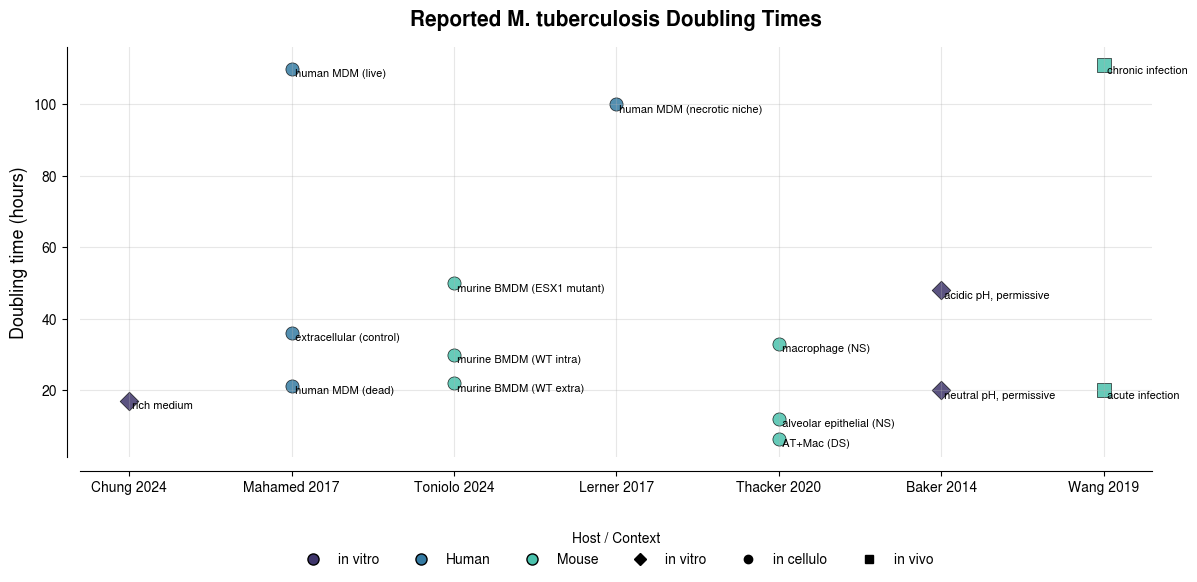

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib import rcParams
import seaborn as sns

# --- Style settings ---
rcParams["font.family"] = "Nimbus Sans" #"Helvetica"
rcParams["axes.spines.top"] = False
rcParams["axes.spines.right"] = False
rcParams["axes.grid"] = True
rcParams["grid.alpha"] = 0.3

# Data with simplified labels
data = [
    ("Chung", "Chung 2024 Nat Micro", 17, "in vitro", "rich medium", "in vitro", 2024),
    
    ("Mahamed", "Mahamed 2017 eLife (live MDM)", 110, "Human", "human MDM (live)", "in cellulo", 2017),
    ("Mahamed", "Mahamed 2017 eLife (dead MDM)", 21.2, "Human", "human MDM (dead)", "in cellulo", 2017),
    ("Mahamed", "Mahamed 2017 eLife (extracellular)", 36.1, "Human", "extracellular (control)", "in cellulo", 2017),
    
    ("Toniolo", "Toniolo 2024 (WT intra)", 30, "Mouse", "murine BMDM (WT intra)", "in cellulo", 2024),
    ("Toniolo", "Toniolo 2024 (WT extra)", 22, "Mouse", "murine BMDM (WT extra)", "in cellulo", 2024),
    ("Toniolo", "Toniolo 2024 (ESX1 intra)", 50, "Mouse", "murine BMDM (ESX1 mutant)", "in cellulo", 2024),
    
    ("Lerner", "Lerner 2017 JCB", 100, "Human", "human MDM (necrotic niche)", "in cellulo", 2017),
    
    ("Thacker", "Thacker 2020 eLife (AT NS)", 12, "Mouse", "alveolar epithelial (NS)", "in cellulo", 2020),
    ("Thacker", "Thacker 2020 eLife (Mac NS)", 33, "Mouse", "macrophage (NS)", "in cellulo", 2020),
    ("Thacker", "Thacker 2020 eLife (AT/Mac DS)", 6.5, "Mouse", "AT+Mac (DS)", "in cellulo", 2020),
    
    ("Baker", "Baker 2014 Mol Micro (neutral)", 20, "in vitro", "neutral pH, permissive", "in vitro", 2014),
    ("Baker", "Baker 2014 Mol Micro (acidic, permissive)", 48, "in vitro", "acidic pH, permissive", "in vitro", 2014),
    
    ("Wang", "Wang 2019 eLife (acute)", 20, "Mouse", "acute infection", "in vivo", 2019),
    ("Wang", "Wang 2019 eLife (chronic)", 111, "Mouse", "chronic infection", "in vivo", 2019),
]

df = pd.DataFrame(data, columns=["Author", "Paper", "DoublingTime_h", "Host", "Label", "Context", "Year"])

# Add combined Author+Year column for x-axis
df["AuthorYear"] = df["Author"] + " " + df["Year"].astype(str)

# Host color palette (mako)
palette = sns.color_palette("mako", n_colors=df["Host"].nunique())
color_map = dict(zip(df["Host"].unique(), palette))

# Context marker mapping
context_map = {"in vitro": "D", "in cellulo": "o", "in vivo": "s"}  # diamond, circle, square

# Plot
plt.figure(figsize=(12, 6))
for _, row in df.iterrows():
    plt.scatter(
        row["AuthorYear"],
        row["DoublingTime_h"],
        color=color_map[row["Host"]],
        marker=context_map[row["Context"]],
        s=90,
        alpha=0.85,
        edgecolor="black",
        linewidth=0.5,
    )

    # Add simplified condition label text
    plt.text(
        row["AuthorYear"],
        row["DoublingTime_h"],
        f" {row['Label']}",
        fontsize=8,
        ha="left",
        va="top",
        rotation=0
    )

# y-axis (log scale recommended)
# plt.yscale("log")
plt.ylabel("Doubling time (hours)", fontsize=13)
# plt.xlabel("First author (Year)", fontsize=13)
plt.title("Reported M. tuberculosis Doubling Times", fontsize=15, weight="bold", pad=15)

plt.xticks(rotation=45, ha="right")

# Legends
host_patches = [plt.Line2D([0], [0], marker="o", color="w",
                           markerfacecolor=color_map[h], markersize=8, markeredgecolor="black",
                           label=h) for h in df["Host"].unique()]

context_patches = [plt.Line2D([0], [0], marker=m, color="k", linestyle="",
                              label=ctx) for ctx, m in context_map.items()]

plt.legend(
    handles=host_patches + context_patches,
    title="Host / Context",
    frameon=False,
    bbox_to_anchor=(0.5, -0.15),  # move below the plot
    loc="upper center",
    ncol=len(host_patches + context_patches)  # put all entries in one row
)
plt.tight_layout()
sns.despine(offset=10)
plt.show()

### With pseudo distributions

In [15]:
df = pd.read_csv('/mnt/OPERA3/Nathan/data/macrohet/dt_lit_dist/dt_lit_dist.csv')

In [16]:
df.keys()

Index(['First author', 'Year', 'Journal', 'Context', 'Host Type',
       'Host cell details', 'Mtb Strain details', 'Culture details',
       'Intrinsic/Extrinsic growth', 'Single-cell doubling time', 'Median (h)',
       'Q1 (h)', 'Q3 (h)', 'N', 'Min dt (h)', 'Max dt (h)', 'Notes', 'Notes.1',
       'Analysis notes', 'PMID', 'Raw data', 'Raw data notes'],
      dtype='object')

/home/dayn/miniconda3/envs/godspee/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/dayn/miniconda3/envs/godspee/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)
/home/dayn/miniconda3/envs/godspee/lib/python3.11/site-packages/seaborn/axisgrid.py:123: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  self._figure.tight_layout(*args, **kwargs)


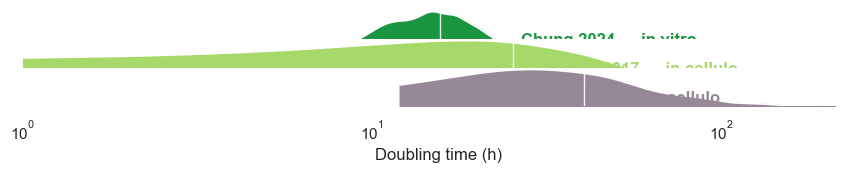

In [17]:
# --- CONFIG ---
csv_path = '/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/dt_lit_dist.csv'# 'for import into python-Table 1.csv' #"/Users/dayn/Documents/mtb growth rate dictionary/for import into python-Table 1.csv"
xmin, xmax = 1, 240  # hours (log scale can't include 0)
palette = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

# --- LOAD + CLEAN ---
df = pd.read_csv(csv_path)

# Ensure numeric cols are numeric
numcols = ["Median (h)", "Q1 (h)", "Q3 (h)", "N", "Min dt (h)", "Max dt (h)"]
for c in numcols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# --- HELPERS: infer log-normal from quartiles and sample ---
from scipy.stats import norm
z25, z75 = norm.ppf(0.25), norm.ppf(0.75)
den = (z75 - z25)  # ~1.349

def ln_params_from_quartiles(med, q1, q3):
    if pd.isna(med) or pd.isna(q1) or pd.isna(q3):
        return None
    if min(med, q1, q3) <= 0:
        return None
    mu = np.log(med)
    sigma = (np.log(q3) - np.log(q1)) / den
    if not np.isfinite(sigma) or sigma <= 0:
        return None
    return mu, sigma

def sample_lognormal(mu, sigma, n, lo=None, hi=None, seed=1979):
    rng = np.random.default_rng(seed)
    draws = rng.lognormal(mu, sigma, size=max(n*5, n+200))
    if lo is not None: draws = draws[draws >= lo]
    if hi is not None: draws = draws[draws <= hi]
    if draws.size < n:  # fallback without truncation if over-filtered
        draws = rng.lognormal(mu, sigma, size=n)
    return draws[:n]

# --- BUILD SYNTHETIC SAMPLES FROM YOUR TABLE ---
rows = []
rng_seed = 1979
for i, r in df.iterrows():
    med, q1, q3 = r.get("Median (h)"), r.get("Q1 (h)"), r.get("Q3 (h)")
    N = int(r.get("N") if pd.notna(r.get("N")) else 300)
    lo = r.get("Min dt (h)") if pd.notna(r.get("Min dt (h)")) else None
    hi = r.get("Max dt (h)") if pd.notna(r.get("Max dt (h)")) else None

    pars = ln_params_from_quartiles(med, q1, q3)
    if pars is None:
        # Rows like “Med=577hr, IQR=-43.3,31.5” (from ln2/k) will land here.
        # Skip for DT ridgelines; handle these separately in k-space if needed.
        continue

    mu, sigma = pars
    samples = sample_lognormal(mu, sigma, N, lo, hi, seed=rng_seed + i)

    # Compose a readable condition label
    label = f"{r.get('First author','?')} {int(r.get('Year')) if pd.notna(r.get('Year')) else ''} — {r.get('Context','')}".strip()
    rows.append(pd.DataFrame({"condition": label, "dt_h": samples}))

if not rows:
    raise RuntimeError("No valid rows to plot (check quartiles are positive).")

df_dt = pd.concat(rows, ignore_index=True)
df_dt = df_dt[df_dt["dt_h"].between(xmin, xmax)].copy()

# --- PLOT: ridgelines on log scale ---
import matplotlib as mpl
mpl.rcParams["font.family"] = "Nimbus Sans" #"Helvetica"

sns.set_theme(style="white")
pal = sns.color_palette(palette, n_colors=df_dt["condition"].nunique())

g = sns.FacetGrid(
    df_dt, row="condition", hue="condition",
    aspect=15, height=0.6, palette=pal,
    sharex=True, sharey=False
)
g.map(
    sns.kdeplot, "dt_h",
    bw_adjust=0.8, fill=True, alpha=1, linewidth=1.2,
    cut=0, clip=(xmin, xmax)
)
g.map(
    sns.kdeplot, "dt_h",
    bw_adjust=0.8, color="w", lw=1.2,
    cut=0, clip=(xmin, xmax)
)

def add_median_line(data, color, **k):
    ax = plt.gca()
    m = np.median(data["dt_h"])
    ax.axvline(m, lw=1, color="w", alpha=0.9)
g.map_dataframe(add_median_line)

def label(_, color, label, **kws):
    ax = plt.gca()
    ax.text(0.6, 0.2, label, fontweight="bold", color=color,
            ha="left", va="center", transform=ax.transAxes)
g.map(label, "dt_h")

g.figure.subplots_adjust(hspace=-0.25)
g.set_titles("")
g.set(yticks=[], ylabel="", xlabel="Doubling time (h)")
g.set(xlim=(xmin, xmax), xscale="log")
sns.despine(bottom=True, left=True, offset=10)
plt.show()

In [18]:
df.loc[0, "Host Type"] = "In Vitro Microfluidic"

In [19]:
df

,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,Q3 (h),N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes
0,Chung,2024,Nat Micro,in vitro,In Vitro Microfluidic,NaN,CDC1551,Rich medium microfluidic device,NaN,Yes,...,19.55,363,4.82,33.55,Single-cell IDT,"Median interdivision, linear growth, not expon...",Single-cell tracking in microfluidic device,PMID: 39548343,Available,Single-cell IDT
1,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular,Intrinsic,No,...,31.50,101,NaN,NaN,Growth rate (ln2),Slow intracellular growth constant shown in li...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2)
2,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular in necrotic macrophages,Extrinsic,No,...,33.00,92,NaN,NaN,Growth rate (ln2),Faster replication after cell death,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2)
3,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular in necrotic macrophages,Extrinsic,No,...,34.00,90,NaN,NaN,"Growth rate (ln2), 2 neg. excluded",Faster replication after cell death,"Median DT calculated from growth constant, neg...",PMID: 28130921,Possibly extractable,"Growth rate (ln2), 2 negative values excluded,..."
4,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Extracellular,Extrinsic,No,...,44.00,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Possibly extractable,"Growth rate (ln2), distribution shown in F5B"
5,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Intracellular in dead alveolar macrophages,Extrinsic,No,...,495.00,220,NaN,NaN,Growth rate (ln2),Comparable between HMDM and AM,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2)
6,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Extracellular near dead alveolar macrophages,Extrinsic,No,...,462.00,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2)
7,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,IFNγ treated,Extrinsic,No,...,91.00,49,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2)
8,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Intracellular,Intrinsic,Yes,...,66.96,59,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B"
9,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Extracellular,Extrinsic,Yes,...,25.76,21,NaN,NaN,"Reciprocal, Fig. 4B",Faster extracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B"


In [20]:

df["ID"] = (
    df["First author"].astype(str)
    + " " 
    + df["Year"].astype(str)
    + ", "
    + df["Journal"].astype(str)
)

plot_df = plot_df.drop(index=3)

NameError: name 'plot_df' is not defined

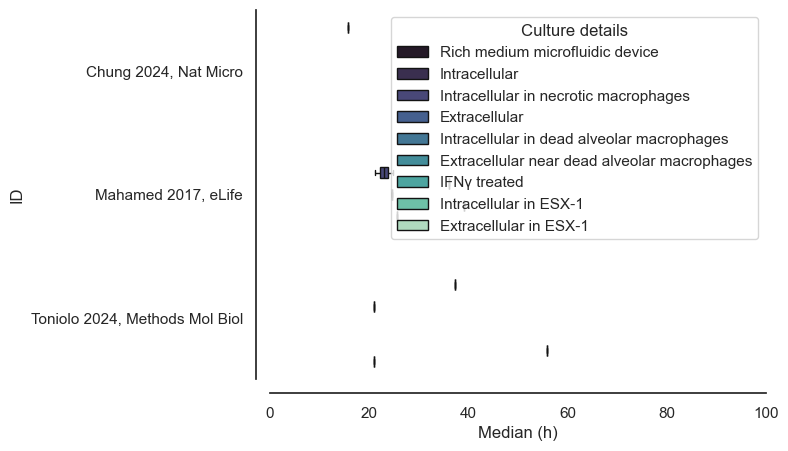

In [21]:
sns.boxplot(data=df, x = 'Median (h)', y = 'ID', hue = 'Culture details', palette = 'mako', )#col='Mtb Strain details')
plt.xlim(0,100)
sns.despine(offset=10)

In [22]:
df.drop(index=3)

,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes,ID
0,Chung,2024,Nat Micro,in vitro,In Vitro Microfluidic,NaN,CDC1551,Rich medium microfluidic device,NaN,Yes,...,363,4.82,33.55,Single-cell IDT,"Median interdivision, linear growth, not expon...",Single-cell tracking in microfluidic device,PMID: 39548343,Available,Single-cell IDT,"Chung 2024, Nat Micro"
1,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular,Intrinsic,No,...,101,NaN,NaN,Growth rate (ln2),Slow intracellular growth constant shown in li...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
2,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular in necrotic macrophages,Extrinsic,No,...,92,NaN,NaN,Growth rate (ln2),Faster replication after cell death,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
4,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Extracellular,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Possibly extractable,"Growth rate (ln2), distribution shown in F5B","Mahamed 2017, eLife"
5,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Intracellular in dead alveolar macrophages,Extrinsic,No,...,220,NaN,NaN,Growth rate (ln2),Comparable between HMDM and AM,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
6,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Extracellular near dead alveolar macrophages,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
7,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,IFNγ treated,Extrinsic,No,...,49,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
8,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Intracellular,Intrinsic,Yes,...,59,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
9,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Extracellular,Extrinsic,Yes,...,21,NaN,NaN,"Reciprocal, Fig. 4B",Faster extracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
10,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,ESX1,Intracellular in ESX-1,Intrinsic,Yes,...,45,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular mutant replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"


# Final draft

In [58]:
# Cell 1: imports, config, load
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import norm

# Style
sns.set_theme(style="white")
mpl.rcParams["font.family"] = "Nimbus Sans" #"Helvetica"

# ---- CONFIG ----
csv_path = '/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/dt_lit_dist.csv'# 'for import into python-Table 1.csv' #"/Users/dayn/Documents/mtb growth rate dictionary/for import into python-Table 1.csv"
xmin, xmax = 1, 120        # plotting range (hours)

# Preferred palette (expanded_piyg)
palette = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

# Load
df = pd.read_csv(csv_path)
df.drop(index=3, inplace=True)
# Ensure numeric
numcols = ["Median (h)", "Q1 (h)", "Q3 (h)", "N", "Min dt (h)", "Max dt (h)"]
for c in numcols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Compose ID label once (you can tweak format here)
df["ID"] = (
    df["First author"].fillna("").astype(str)
    + " " + df["Year"].fillna("").astype(str)
    + ", " + df["Journal"].fillna("").astype(str)
)

# Optional: keep only rows with quartiles + N present
df = df.dropna(subset=["Median (h)", "Q1 (h)", "Q3 (h)", "N"]).copy()

In [59]:
# cell 1.5 add our data
our_df = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl')

In [60]:
df_mask = ((our_df['Strain'] == 'WT') &
          (our_df['Compound'] == 'CTRL') &
          (our_df['Concentration'] == 'EC0') &
          (our_df['mtb_origin'] == 'Growth')
           )

our_dts = our_df[df_mask].drop_duplicates('ID').explode('Doubling Times')['Doubling Times']

our_dts = our_dts[our_dts >0]

# median
median = our_dts.median()

# first quartile (25th percentile)
q1 = our_dts.quantile(0.25)

# third quartile (75th percentile)
q3 = our_dts.quantile(0.75)

N = len(our_df[df_mask].drop_duplicates('ID'))
print(f"Median: {median}, Q1: {q1}, Q3: {q3}, N: {N}")

Median: 24.75, Q1: 19.0, Q3: 33.0, N: 219


In [61]:
new_row = {
    'First author': 'Day, Pradel, Luk',
    'Year': 2025,
    'Journal': 'TBC',
    'Context': 'in cellulo',
    'Host Type': 'Human',
    'Host cell details': 'IPSDM',
    'Mtb Strain details': 'H37Rv',
    'Culture details': 'Intracellular',
    'Intrinsic/Extrinsic growth': 'Intrinsic',
    'Single-cell doubling time': 'Yes',
    'Median (h)': median,
    'Q1 (h)': q1,
    'Q3 (h)': q3,
    'N': N,  # sample size if you want
    'Min dt (h)': our_dts.min(),
    'Max dt (h)': our_dts.max(),
    'Notes': '',
    'Notes.1': '',
    'Analysis notes': '',
    'PMID': '',
    'Raw data': '',
    'Raw data notes': '',
    'ID': 'Day, Pradel, Luk, 2025'
}

# append row
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


In [62]:
# 1. Filter the dataframe
rd1_mask = (
    (our_df['Strain'] == 'RD1')
    & (our_df['Compound'] == 'CTRL')
    & (our_df['Concentration'] == 'EC0')
    & (our_df['mtb_origin'] == 'Growth')
)
# 2. Extract and clean doubling times
rd1_dts = (
    our_df[rd1_mask]
    .drop_duplicates('ID')                # ensure unique cells
    .explode('Doubling Times')['Doubling Times']  # flatten lists
)
rd1_dts = rd1_dts[rd1_dts > 0]             # remove invalid / non-positive

# 3. Compute stats
rd1_median = rd1_dts.median()
rd1_q1 = rd1_dts.quantile(0.25)
rd1_q3 = rd1_dts.quantile(0.75)
rd1_N = len(our_df[rd1_mask].drop_duplicates('ID'))

# 4. Print summary
print(f"RD1  →  Median: {rd1_median:.2f} h | Q1: {rd1_q1:.2f} h | Q3: {rd1_q3:.2f} h | N: {rd1_N}")


RD1  →  Median: 39.50 h | Q1: 20.75 h | Q3: 58.25 h | N: 83


In [63]:
new_row = {
    'First author': 'Day, Pradel, Luk',
    'Year': 2025,
    'Journal': 'TBC',
    'Context': 'in cellulo',
    'Host Type': 'Human',
    'Host cell details': 'IPSDM',
    'Mtb Strain details': 'ΔRD1',
    'Culture details': 'Intracellular ΔRD1',
    'Intrinsic/Extrinsic growth': 'Intrinsic',
    'Single-cell doubling time': 'Yes',
    'Median (h)': rd1_median,
    'Q1 (h)': rd1_q1,
    'Q3 (h)': rd1_q3,
    'N': rd1_N,  # sample size if you want
    'Min dt (h)': rd1_dts.min(),
    'Max dt (h)': rd1_dts.max(),
    'Notes': '',
    'Notes.1': '',
    'Analysis notes': '',
    'PMID': '',
    'Raw data': '',
    'Raw data notes': '',
    'ID': 'Day, Pradel, Luk, 2025'
}

# append row
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


In [64]:
df

,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes,ID
0,Chung,2024,Nat Micro,in vitro,NaN,NaN,CDC1551,Rich medium microfluidic device,NaN,Yes,...,363,4.82,33.55,Single-cell IDT,"Median interdivision, linear growth, not expon...",Single-cell tracking in microfluidic device,PMID: 39548343,Available,Single-cell IDT,"Chung 2024, Nat Micro"
1,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular,Intrinsic,No,...,101,NaN,NaN,Growth rate (ln2),Slow intracellular growth constant shown in li...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
2,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular in necrotic macrophages,Extrinsic,No,...,92,NaN,NaN,Growth rate (ln2),Faster replication after cell death,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
3,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Extracellular,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Possibly extractable,"Growth rate (ln2), distribution shown in F5B","Mahamed 2017, eLife"
4,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Intracellular in dead alveolar macrophages,Extrinsic,No,...,220,NaN,NaN,Growth rate (ln2),Comparable between HMDM and AM,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
5,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Extracellular near dead alveolar macrophages,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
6,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,IFNγ treated,Extrinsic,No,...,49,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
7,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Intracellular,Intrinsic,Yes,...,59,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
8,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Extracellular,Extrinsic,Yes,...,21,NaN,NaN,"Reciprocal, Fig. 4B",Faster extracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
9,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,ESX1,Intracellular in ESX-1,Intrinsic,Yes,...,45,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular mutant replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"


In [65]:
# Cell 2: build Gaussian-based plot_df (no recompute needed later)
# Gaussian with mu = Median(h); sigma from IQR: sigma = (Q3 - Q1) / (2*z0.75)

zq = 0.67448975  # Phi^{-1}(0.75)
npoints = 300
xs = np.linspace(xmin, xmax, npoints)

def gaussian_plot_rows(df_in):
    rows = []
    for _, r in df_in.iterrows():
        med, q1, q3, N = r["Median (h)"], r["Q1 (h)"], r["Q3 (h)"], r["N"]
        mu = float(med)
        sigma = (float(q3) - float(q1)) / (2.0 * zq)
        if not np.isfinite(sigma) or sigma <= 0 or not np.isfinite(mu):
            continue

        pdf = np.exp(-0.5 * ((xs - mu) / sigma)**2) / (sigma * np.sqrt(2*np.pi))
        pdf = pdf / pdf.max() * np.sqrt(float(N))   # peak ∝ √N

        rows.append(pd.DataFrame({
            "x": xs,
            "y": pdf,
            "ID": r["ID"],
            "Culture details": r["Culture details"]
        }))
    if not rows:
        return pd.DataFrame(columns=["x","y","ID","Culture details"])
    return pd.concat(rows, ignore_index=True)

plot_df = gaussian_plot_rows(df)
plot_df.head()

,x,y,ID,Culture details
0,1.000000,0.045601,"Chung 2024, Nat Micro",Rich medium microfluidic device
1,1.397993,0.062975,"Chung 2024, Nat Micro",Rich medium microfluidic device
2,1.795987,0.086200,"Chung 2024, Nat Micro",Rich medium microfluidic device
3,2.193980,0.116947,"Chung 2024, Nat Micro",Rich medium microfluidic device
4,2.591973,0.157261,"Chung 2024, Nat Micro",Rich medium microfluidic device


In [66]:
plot_df

,x,y,ID,Culture details
0,1.000000,0.045601,"Chung 2024, Nat Micro",Rich medium microfluidic device
1,1.397993,0.062975,"Chung 2024, Nat Micro",Rich medium microfluidic device
2,1.795987,0.086200,"Chung 2024, Nat Micro",Rich medium microfluidic device
3,2.193980,0.116947,"Chung 2024, Nat Micro",Rich medium microfluidic device
4,2.591973,0.157261,"Chung 2024, Nat Micro",Rich medium microfluidic device
...,...,...,...,...
3895,118.408027,0.162150,"Day, Pradel, Luk, 2025",Intracellular ΔRD1
3896,118.806020,0.155677,"Day, Pradel, Luk, 2025",Intracellular ΔRD1
3897,119.204013,0.149431,"Day, Pradel, Luk, 2025",Intracellular ΔRD1
3898,119.602007,0.143407,"Day, Pradel, Luk, 2025",Intracellular ΔRD1


In [67]:
# Cell 3: adaptive layout helpers (spacing only)
def compute_layout(plot_df, df_summary,
                   height_scale=1.0, gain=2.0,
                   substep_min=10.0, k_sub=0.9,
                   base_gap=6.0, k_gap=0.5):
    """
    Returns: ids_order, peaks, id_specs, y_center, base_for, colors
    All computed from plot_df; you can change the knobs without rebuilding plot_df.
    """
    # Tallest ridge per (ID, culture) in plot units
    peaks = (plot_df.groupby(["ID","Culture details"])["y"]
                   .max()
                   .mul(height_scale * gain)
                   .rename("ypeak")
                   .reset_index())

    ids_order = list(pd.unique(plot_df["ID"]))

    # Adaptive substep and half-height per ID
    id_specs, id_substep = {}, {}
    for idv in ids_order:
        cults = list(pd.unique(plot_df.loc[plot_df["ID"] == idv, "Culture details"]))
        ypeak_max = peaks.loc[peaks["ID"] == idv, "ypeak"].max()
        sub_i = max(substep_min, k_sub * float(ypeak_max))
        half  = 0.5*((len(cults)-1)*sub_i) + 0.5*float(ypeak_max)
        id_specs[idv]  = {"cults": cults, "half": half, "ypeak_max": float(ypeak_max)}
        id_substep[idv] = sub_i

    # Place groups with adaptive gap
    y_center, current_y = {}, 0.0
    for i, idv in enumerate(ids_order):
        half = id_specs[idv]["half"]
        if i == 0:
            y_center[idv] = 0.0
        else:
            prev = ids_order[i-1]
            gap_i = max(base_gap, k_gap * max(id_specs[prev]["ypeak_max"], id_specs[idv]["ypeak_max"]))
            y_center[idv] = current_y - (id_specs[prev]["half"] + gap_i + half)
        current_y = y_center[idv]

    # Baselines for each (ID, culture) centered and equally spaced
    base_for = {}
    for idv in ids_order:
        cults = id_specs[idv]["cults"]
        sub_i = id_substep[idv]
        n_c   = len(cults)
        for j, cult in enumerate(cults):
            base_for[(idv, cult)] = y_center[idv] - (n_c - 1) * sub_i / 2.0 + j * sub_i

    # Colors for Culture details using PiYG colormap
    cult_levels = pd.unique(plot_df["Culture details"])
    n_cults     = len(cult_levels)
    
    # make a PiYG palette long enough (repeats if n_cults > base palette size)
    pal = sns.color_palette("rocket", n_colors=n_cults)
    
    # assign colors per culture detail
    colors = {c: pal[i % len(pal)] for i, c in enumerate(cult_levels)}
    return ids_order, peaks, id_specs, y_center, base_for, colors

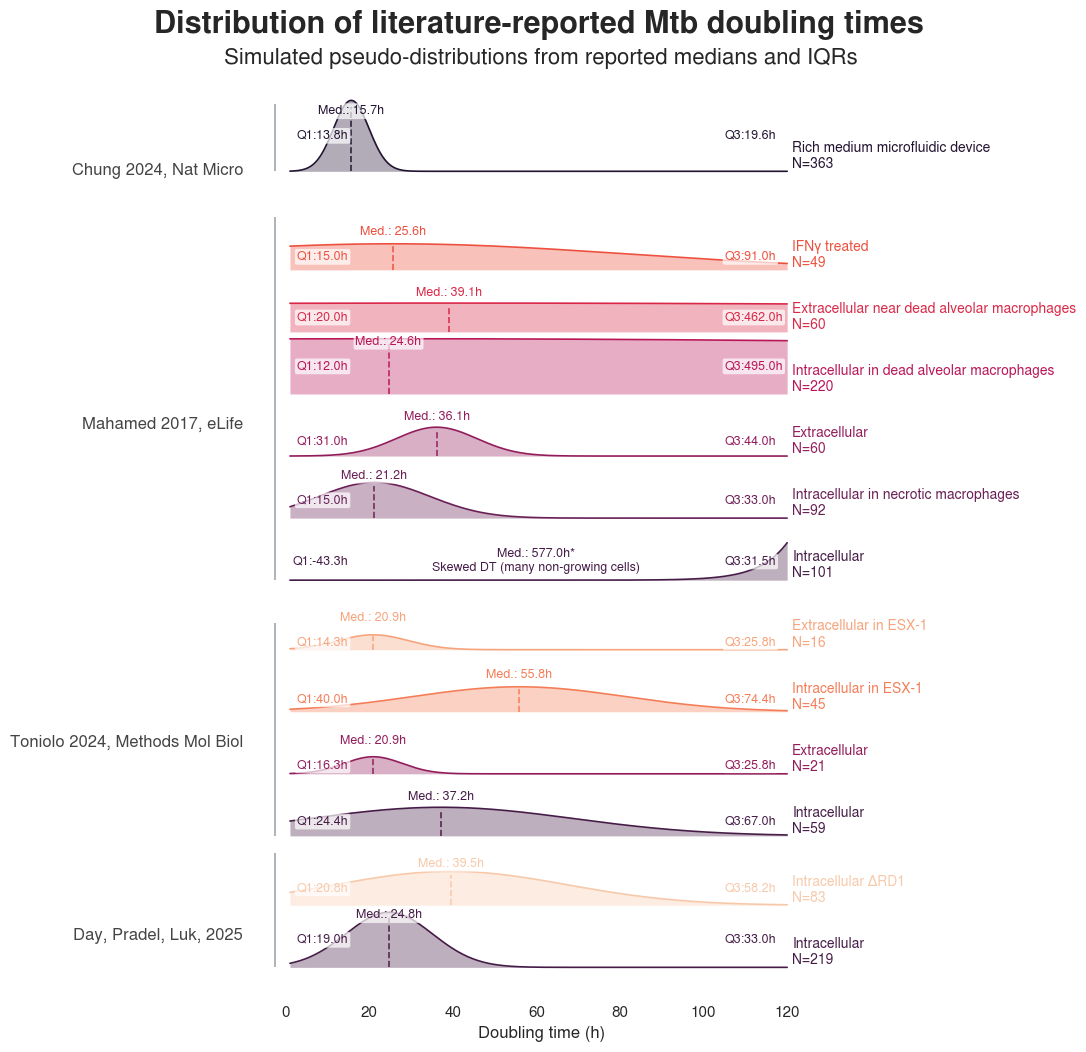

In [68]:
# Cell 4: plot (adjust knobs here; no distribution recompute)
height_scale = 1.0     # ridge height base
gain         = 3.0     # global height gain (try 1.5–3.0)
substep_min  = 50.0    # min spacing inside an ID
k_sub        = 0.9     # within-ID spacing factor vs tallest ridge
base_gap     = .0     # minimal gap between ID groups
k_gap        = 0.5     # extra gap factor vs tallest ridge

ids_order, peaks, id_specs, y_center, base_for, colors = compute_layout(
    plot_df, df,
    height_scale=height_scale, gain=gain,
    substep_min=substep_min, k_sub=k_sub,
    base_gap=base_gap, k_gap=k_gap
)

fig_h = max(10, 0.85 * len(ids_order))
fig, ax = plt.subplots(figsize=(11, fig_h))

# Draw ridges + medians + inline labels + quartile tags
for (idv, cult), d in plot_df.groupby(["ID", "Culture details"], sort=False):
    base  = base_for[(idv, cult)]
    ypeak = d["y"].max() * height_scale * gain
    yplot = base + d["y"] * height_scale * gain
    col   = colors[cult]

    ax.fill_between(d["x"], base, yplot, color=col, alpha=0.35, linewidth=0)
    ax.plot(d["x"], yplot, color=col, lw=1.2)

    # dashed median
    med = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "Median (h)"]
    if not med.empty and med.values[0] > 0:
        ax.vlines(med.values[0], base, base + 0.9 * ypeak,
                  colors=col, linestyles="--", lw=1.2, alpha=0.9)
    
    N_series = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "N"]
    N_text = f"N={int(N_series.values[0])}" if (not N_series.empty and pd.notna(N_series.values[0])) else "N=NA"
    # ax.text(
    #     xmax * 1.01, base + 0.5 * ypeak, N_text,             # move closer/farther with this offset
    #     ha="left", va="top", fontsize=9, color=col,
    #     bbox=dict(boxstyle="round,pad=0.1", fc="white", ec="none", alpha=0.7),
    #     zorder=5
    # )
    
    # inline label
    ax.text(xmax * 1.01, base, cult+f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col)


    # get quartiles for this (ID, Culture)
    row = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult),
                 ["Q1 (h)", "Median (h)", "Q3 (h)"]]

    if not row.empty:
        q1, medx, q3 = row.iloc[0]["Q1 (h)"], row.iloc[0]["Median (h)"], row.iloc[0]["Q3 (h)"]
        
        # vertical anchor roughly through the middle of this ridge
        y_anchor = base + 0.5 * ypeak
    
        # gutters at plot extents (use same xpad you already compute below)
        xpad_local = 0.03 * (xmax - xmin)   # small horizontal padding
        x_left  = 15 #xmin - 1.5 * xpad_local
        x_right = 105 #xmax * 1.04               # a hair inside the right extension
    
        # Q1 → left gutter
        if pd.notna(q1):
            ax.text(
                x_left, y_anchor, f"Q1:{q1:.1f}h",
                ha="right", va="center", fontsize=9, color=col,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                zorder=5
            )
    
        # Med → at the median x (keep your dashed vline if inside plot)
        if pd.notna(medx):
            if xmin <= medx <= xmax:
                # inside range → plot at actual median
                ax.text(
                    medx, y_anchor + 15, f"Med.: {medx:.1f}h",
                    ha="center", va="bottom", fontsize=9, color=col,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                    zorder=5
                )
            else:
                # outside → place at xmax/2 with asterisk
                ax.text(
                    xmax/2, y_anchor - 10, f"Med.: {medx:.1f}h*\nSkewed DT (many non-growing cells)",
                    ha="center", va="bottom", fontsize=9, color=col,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                    zorder=5
                )
    
        # Q3 → right gutter
        if pd.notna(q3):
            ax.text(
                x_right, y_anchor, f"Q3:{q3:.1f}h",
                ha="left", va="center", fontsize=9, color=col,
                bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                zorder=5
            )
            
# Vertical group lines per ID
span = {}
for idv in ids_order:
    bases = [base_for[(idv, c)] for c in id_specs[idv]["cults"]]
    y_low = min(bases)
    ypeak_max = peaks.loc[peaks["ID"] == idv, "ypeak"].max()
    y_high = max(bases) + 0.95 * ypeak_max
    span[idv] = (y_low, y_high)

xpad  = 0.03 * (xmax - xmin)
xline = xmin - xpad
for idv in ids_order:
    y0, y1 = span[idv]
    ax.vlines(xline, y0, y1, colors="#9aa0a6", linestyles="-", lw=1.4, alpha=0.8)

# Axes + labels
ax.set_xlim(xmin - 2 * xpad, xmax * 1.07)
ymin = min(y_center.values()) - max(v["half"] for v in id_specs.values()) - base_gap
ymax = max(y_center.values()) + max(v["half"] for v in id_specs.values()) + base_gap
# ax.set_ylim(ymin, ymax)

y_allmin = min(v[0] for v in span.values())
y_allmax = max(v[1] for v in span.values())
ypad = 0.03 * (y_allmax - y_allmin)  # small breathing room

ax.set_ylim(y_allmin - ypad, y_allmax + ypad)
ax.margins(y=0)  

# IDs outside on the left
from matplotlib.transforms import blended_transform_factory
ax.set_yticks([]); ax.set_ylabel("")
plt.subplots_adjust(left=0.32, right=0.92)
bt = blended_transform_factory(ax.transAxes, ax.transData)
for idv in ids_order:
    ax.text(-0.03, y_center[idv], idv, transform=bt,
            ha="right", va="center", fontsize=12, color="#444", clip_on=False)

ax.set_xlabel("Doubling time (h)")
sns.despine(left=True, bottom=True, offset=10)
plt.tight_layout()

# Main title
fig.suptitle(
    "Distribution of literature-reported Mtb doubling times",
    fontsize=22, fontweight="bold", y=1.05
)
ax.set_title(
    "Simulated pseudo-distributions from reported medians and IQRs",
    fontsize=16, fontweight="normal", pad=10
)
# plt.savefig('psuedo_dist.pdf', bbox_inches='tight',dpi=314)
plt.show()

## Adding antibiotics

In [69]:
# Cell 1: imports, config, load
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy.stats import norm

# Style
sns.set_theme(style="white")
mpl.rcParams["font.family"] = "Nimbus Sans" #"Helvetica"

# ---- CONFIG ----
csv_path = '/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/dt_lit_dist.csv'# 'for import into python-Table 1.csv' #"/Users/dayn/Documents/mtb growth rate dictionary/for import into python-Table 1.csv"
xmin, xmax = 1, 120        # plotting range (hours)

# Preferred palette (expanded_piyg)
palette = ['#1a9641', '#a6d96a', '#978897', '#d1d1ca', '#f1b6da', '#d02c91']

# Load
df = pd.read_csv(csv_path)
df.drop(index=3, inplace=True)
# Ensure numeric
numcols = ["Median (h)", "Q1 (h)", "Q3 (h)", "N", "Min dt (h)", "Max dt (h)"]
for c in numcols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Compose ID label once (you can tweak format here)
df["ID"] = (
    df["First author"].fillna("").astype(str)
    + " " + df["Year"].fillna("").astype(str)
    + ", " + df["Journal"].fillna("").astype(str)
)

# Optional: keep only rows with quartiles + N present
df = df.dropna(subset=["Median (h)", "Q1 (h)", "Q3 (h)", "N"]).copy()

In [70]:
# cell 1.5 add our data
our_df = pd.read_pickle('/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/dfs/sc_df.pkl')

In [71]:
df_mask = ((our_df['Strain'] == 'WT') &
          (our_df['Compound'] == 'CTRL') &
          (our_df['Concentration'] == 'EC0') &
          (our_df['mtb_origin'] == 'Growth')
           )

our_dts = our_df[df_mask].drop_duplicates('ID').explode('Doubling Times')['Doubling Times']

our_dts = our_dts[our_dts >0]

# median
median = our_dts.median()

# first quartile (25th percentile)
q1 = our_dts.quantile(0.25)

# third quartile (75th percentile)
q3 = our_dts.quantile(0.75)

N = len(our_df[df_mask].drop_duplicates('ID'))
print(f"Median: {median}, Q1: {q1}, Q3: {q3}, N: {N}")

new_row = {
    'First author': 'Day, Pradel, Luk',
    'Year': 2025,
    'Journal': 'TBC',
    'Context': 'in cellulo',
    'Host Type': 'Human',
    'Host cell details': 'IPSDM',
    'Mtb Strain details': 'H37Rv',
    'Culture details': 'Intracellular',
    'Intrinsic/Extrinsic growth': 'Intrinsic',
    'Single-cell doubling time': 'Yes',
    'Median (h)': median,
    'Q1 (h)': q1,
    'Q3 (h)': q3,
    'N': N,  # sample size if you want
    'Min dt (h)': our_dts.min(),
    'Max dt (h)': our_dts.max(),
    'Notes': '',
    'Notes.1': '',
    'Analysis notes': '',
    'PMID': '',
    'Raw data': '',
    'Raw data notes': '',
    'ID': 'Day, Pradel, Luk, 2025'
}

# append row
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


# 1. Filter the dataframe
rd1_mask = (
    (our_df['Strain'] == 'RD1')
    & (our_df['Compound'] == 'CTRL')
    & (our_df['Concentration'] == 'EC0')
    & (our_df['mtb_origin'] == 'Growth')
)
# 2. Extract and clean doubling times
rd1_dts = (
    our_df[rd1_mask]
    .drop_duplicates('ID')                # ensure unique cells
    .explode('Doubling Times')['Doubling Times']  # flatten lists
)
rd1_dts = rd1_dts[rd1_dts > 0]             # remove invalid / non-positive

# 3. Compute stats
rd1_median = rd1_dts.median()
rd1_q1 = rd1_dts.quantile(0.25)
rd1_q3 = rd1_dts.quantile(0.75)
rd1_N = len(our_df[rd1_mask].drop_duplicates('ID'))

# 4. Print summary
print(f"RD1  →  Median: {rd1_median:.2f} h | Q1: {rd1_q1:.2f} h | Q3: {rd1_q3:.2f} h | N: {rd1_N}")


new_row = {
    'First author': 'Day, Pradel, Luk',
    'Year': 2025,
    'Journal': 'TBC',
    'Context': 'in cellulo',
    'Host Type': 'Human',
    'Host cell details': 'IPSDM',
    'Mtb Strain details': 'ΔRD1',
    'Culture details': 'Intracellular ΔRD1',
    'Intrinsic/Extrinsic growth': 'Intrinsic',
    'Single-cell doubling time': 'Yes',
    'Median (h)': rd1_median,
    'Q1 (h)': rd1_q1,
    'Q3 (h)': rd1_q3,
    'N': rd1_N,  # sample size if you want
    'Min dt (h)': rd1_dts.min(),
    'Max dt (h)': rd1_dts.max(),
    'Notes': '',
    'Notes.1': '',
    'Analysis notes': '',
    'PMID': '',
    'Raw data': '',
    'Raw data notes': '',
    'ID': 'Day, Pradel, Luk, 2025'
}

# append row
df = pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


df

Median: 24.75, Q1: 19.0, Q3: 33.0, N: 219
RD1  →  Median: 39.50 h | Q1: 20.75 h | Q3: 58.25 h | N: 83


,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes,ID
0,Chung,2024,Nat Micro,in vitro,NaN,NaN,CDC1551,Rich medium microfluidic device,NaN,Yes,...,363,4.82,33.55,Single-cell IDT,"Median interdivision, linear growth, not expon...",Single-cell tracking in microfluidic device,PMID: 39548343,Available,Single-cell IDT,"Chung 2024, Nat Micro"
1,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular,Intrinsic,No,...,101,NaN,NaN,Growth rate (ln2),Slow intracellular growth constant shown in li...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
2,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Intracellular in necrotic macrophages,Extrinsic,No,...,92,NaN,NaN,Growth rate (ln2),Faster replication after cell death,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
3,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,Extracellular,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Possibly extractable,"Growth rate (ln2), distribution shown in F5B","Mahamed 2017, eLife"
4,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Intracellular in dead alveolar macrophages,Extrinsic,No,...,220,NaN,NaN,Growth rate (ln2),Comparable between HMDM and AM,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
5,Mahamed,2017,eLife,in cellulo,Human,AMs,H37Rv,Extracellular near dead alveolar macrophages,Extrinsic,No,...,60,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
6,Mahamed,2017,eLife,in cellulo,Human,MDMs,H37Rv,IFNγ treated,Extrinsic,No,...,49,NaN,NaN,Growth rate (ln2),Slower extracellular replication compared to d...,Median DT calculated from growth constant,PMID: 28130921,Not shown,Growth rate (ln2),"Mahamed 2017, eLife"
7,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Intracellular,Intrinsic,Yes,...,59,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
8,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,H37Rv,Extracellular,Extrinsic,Yes,...,21,NaN,NaN,"Reciprocal, Fig. 4B",Faster extracellular replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"
9,Toniolo,2024,Methods Mol Biol,in cellulo,Murine,BMDMs,ESX1,Intracellular in ESX-1,Intrinsic,Yes,...,45,NaN,NaN,"Reciprocal, Fig. 4B",Slower intracellular mutant replication,Exponential fits of microcolony area,PMID: 38888778,Possibly extractable,"Reciprocal, distribution shown in F4B","Toniolo 2024, Methods Mol Biol"


In [72]:
# ------------------------------------------
# Helper to avoid repetition
# ------------------------------------------
def add_condition_row(df, our_df, strain, compound, conc, origin,
                      label, culture_label):
    """
    Filter our_df, compute stats, and append a new row to df.
    """
    mask = (
        (our_df['Strain'] == strain)
        & (our_df['Compound'] == compound)
        & (our_df['Concentration'] == conc)
        & (our_df['mtb_origin'] == origin)
    )

    dts = (
        our_df[mask]
        .drop_duplicates('ID')
        .explode('Doubling Times')['Doubling Times']
    )
    dts = dts[dts > 0]

    median = dts.median()
    q1 = dts.quantile(0.25)
    q3 = dts.quantile(0.75)
    N = len(our_df[mask].drop_duplicates('ID'))

    print(f"{label} → Median: {median:.2f} h | Q1: {q1:.2f} h | Q3: {q3:.2f} h | N: {N}")

    new_row = {
        'First author': 'Day, Pradel, Luk',
        'Year': 2025,
        'Journal': 'TBC',
        'Context': 'in cellulo',
        'Host Type': 'Human',
        'Host cell details': 'IPSDM',
        'Mtb Strain details': 'H37Rv',
        'Culture details': culture_label,
        'Intrinsic/Extrinsic growth': 'Intrinsic',
        'Single-cell doubling time': 'Yes',
        'Median (h)': median,
        'Q1 (h)': q1,
        'Q3 (h)': q3,
        'N': N,
        'Min dt (h)': dts.min(),
        'Max dt (h)': dts.max(),
        'Notes': '',
        'Notes.1': '',
        'Analysis notes': '',
        'PMID': '',
        'Raw data': '',
        'Raw data notes': '',
        'ID': f'Day, Pradel, Luk, 2025'
    }

    return pd.concat([df, pd.DataFrame([new_row])], ignore_index=True)


# ------------------------------------------
# Add WT–PZA, WT–INH, WT–RIF
# ------------------------------------------

df = add_condition_row(df, our_df,
                       strain='WT',
                       compound='PZA',
                       conc='EC99',
                       origin='Growth',
                       label='WT + PZA',
                       culture_label='Intracellular PZA treated')

df = add_condition_row(df, our_df,
                       strain='WT',
                       compound='INH',
                       conc='EC99',
                       origin='Growth',
                       label='WT + INH',
                       culture_label='Intracellular INH treated')

df = add_condition_row(df, our_df,
                       strain='WT',
                       compound='RIF',
                       conc='EC99',
                       origin='Growth',
                       label='WT + RIF',
                       culture_label='Intracellular RIF treated')


# Show updated table
df.tail(5)


WT + PZA → Median: 24.50 h | Q1: 14.50 h | Q3: 40.00 h | N: 24
WT + INH → Median: 19.50 h | Q1: 10.25 h | Q3: 44.25 h | N: 46
WT + RIF → Median: 9.50 h | Q1: 6.50 h | Q3: 25.50 h | N: 29


,First author,Year,Journal,Context,Host Type,Host cell details,Mtb Strain details,Culture details,Intrinsic/Extrinsic growth,Single-cell doubling time,...,N,Min dt (h),Max dt (h),Notes,Notes.1,Analysis notes,PMID,Raw data,Raw data notes,ID
11,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular,Intrinsic,Yes,...,219,4.0,68.0,,,,,,,"Day, Pradel, Luk, 2025"
12,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,ΔRD1,Intracellular ΔRD1,Intrinsic,Yes,...,83,7.0,68.0,,,,,,,"Day, Pradel, Luk, 2025"
13,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular PZA treated,Intrinsic,Yes,...,24,4.0,73.5,,,,,,,"Day, Pradel, Luk, 2025"
14,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular INH treated,Intrinsic,Yes,...,46,1.5,67.0,,,,,,,"Day, Pradel, Luk, 2025"
15,"Day, Pradel, Luk",2025,TBC,in cellulo,Human,IPSDM,H37Rv,Intracellular RIF treated,Intrinsic,Yes,...,29,3.0,48.0,,,,,,,"Day, Pradel, Luk, 2025"


In [73]:
# Cell 2: build Gaussian-based plot_df (no recompute needed later)
# Gaussian with mu = Median(h); sigma from IQR: sigma = (Q3 - Q1) / (2*z0.75)

zq = 0.67448975  # Phi^{-1}(0.75)
npoints = 300
xs = np.linspace(xmin, xmax, npoints)

def gaussian_plot_rows(df_in):
    rows = []
    for _, r in df_in.iterrows():
        med, q1, q3, N = r["Median (h)"], r["Q1 (h)"], r["Q3 (h)"], r["N"]
        mu = float(med)
        sigma = (float(q3) - float(q1)) / (2.0 * zq)
        if not np.isfinite(sigma) or sigma <= 0 or not np.isfinite(mu):
            continue

        pdf = np.exp(-0.5 * ((xs - mu) / sigma)**2) / (sigma * np.sqrt(2*np.pi))
        pdf = pdf / pdf.max() * np.sqrt(float(N))   # peak ∝ √N

        rows.append(pd.DataFrame({
            "x": xs,
            "y": pdf,
            "ID": r["ID"],
            "Culture details": r["Culture details"]
        }))
    if not rows:
        return pd.DataFrame(columns=["x","y","ID","Culture details"])
    return pd.concat(rows, ignore_index=True)

plot_df = gaussian_plot_rows(df)
plot_df.head()

,x,y,ID,Culture details
0,1.000000,0.045601,"Chung 2024, Nat Micro",Rich medium microfluidic device
1,1.397993,0.062975,"Chung 2024, Nat Micro",Rich medium microfluidic device
2,1.795987,0.086200,"Chung 2024, Nat Micro",Rich medium microfluidic device
3,2.193980,0.116947,"Chung 2024, Nat Micro",Rich medium microfluidic device
4,2.591973,0.157261,"Chung 2024, Nat Micro",Rich medium microfluidic device


In [74]:
# --- adaptive layout (unchanged) ---
def compute_layout(plot_df, df_summary,
                   height_scale=1.0, gain=2.0,
                   substep_min=10.0, k_sub=0.9,
                   base_gap=6.0, k_gap=0.5):
    """
    Returns: ids_order, peaks, id_specs, y_center, base_for, colors
    """
    peaks = (plot_df.groupby(["ID","Culture details"])["y"]
                   .max()
                   .mul(height_scale * gain)
                   .rename("ypeak")
                   .reset_index())

    ids_order = list(pd.unique(plot_df["ID"]))

    id_specs, id_substep = {}, {}
    for idv in ids_order:
        cults = list(pd.unique(plot_df.loc[plot_df["ID"] == idv, "Culture details"]))
        ypeak_max = peaks.loc[peaks["ID"] == idv, "ypeak"].max()
        sub_i = max(substep_min, k_sub * float(ypeak_max))
        half  = 0.5*((len(cults)-1)*sub_i) + 0.5*float(ypeak_max)
        id_specs[idv]  = {"cults": cults, "half": half, "ypeak_max": float(ypeak_max)}
        id_substep[idv] = sub_i

    y_center, current_y = {}, 0.0
    for i, idv in enumerate(ids_order):
        half = id_specs[idv]["half"]
        if i == 0:
            y_center[idv] = 0.0
        else:
            prev = ids_order[i-1]
            gap_i = max(base_gap, k_gap * max(id_specs[prev]["ypeak_max"], id_specs[idv]["ypeak_max"]))
            y_center[idv] = current_y - (id_specs[prev]["half"] + gap_i + half)
        current_y = y_center[idv]

    base_for = {}
    for idv in ids_order:
        cults = id_specs[idv]["cults"]
        sub_i = id_substep[idv]
        n_c   = len(cults)
        for j, cult in enumerate(cults):
            base_for[(idv, cult)] = y_center[idv] - (n_c - 1) * sub_i / 2.0 + j * sub_i

    # simple per-culture fallback palette (used only if no median found)
    cult_levels = pd.unique(plot_df["Culture details"])
    pal = sns.color_palette("rocket", n_colors=len(cult_levels))
    colors = {c: pal[i % len(pal)] for i, c in enumerate(cult_levels)}
    return ids_order, peaks, id_specs, y_center, base_for, colors


# --- layout knobs ---
height_scale = 1.0
gain         = 3.0
substep_min  = 50.0
k_sub        = 0.9
base_gap     = 0.0
k_gap        = 0.5

ids_order, peaks, id_specs, y_center, base_for, colors = compute_layout(
    plot_df, df,
    height_scale=height_scale, gain=gain,
    substep_min=substep_min, k_sub=k_sub,
    base_gap=base_gap, k_gap=k_gap
)

# --- x-range (robust if not previously set) ---
xmin = 0 #float(plot_df["x"].min())
xmax = 120 #float(plot_df["x"].max())

# --- Median-based color mapping (smaller DT = darker) ---
from matplotlib import colors as mcolors
med_map = (
    df.set_index(["ID", "Culture details"])["Median (h)"]
      .dropna()
)

vmin, vmax = 0, 55.8 #float(med_map.min()), float(med_map.max())
cmap = sns.color_palette("rocket_r", as_cmap=True)   # dark → light
norm = mcolors.Normalize(vmin=vmin, vmax=vmax)

# color for each (ID, Culture details)
colors_by_pair = {k: cmap(norm(v)) for k, v in med_map.items()}


In [75]:
cult

'Intracellular ΔRD1'

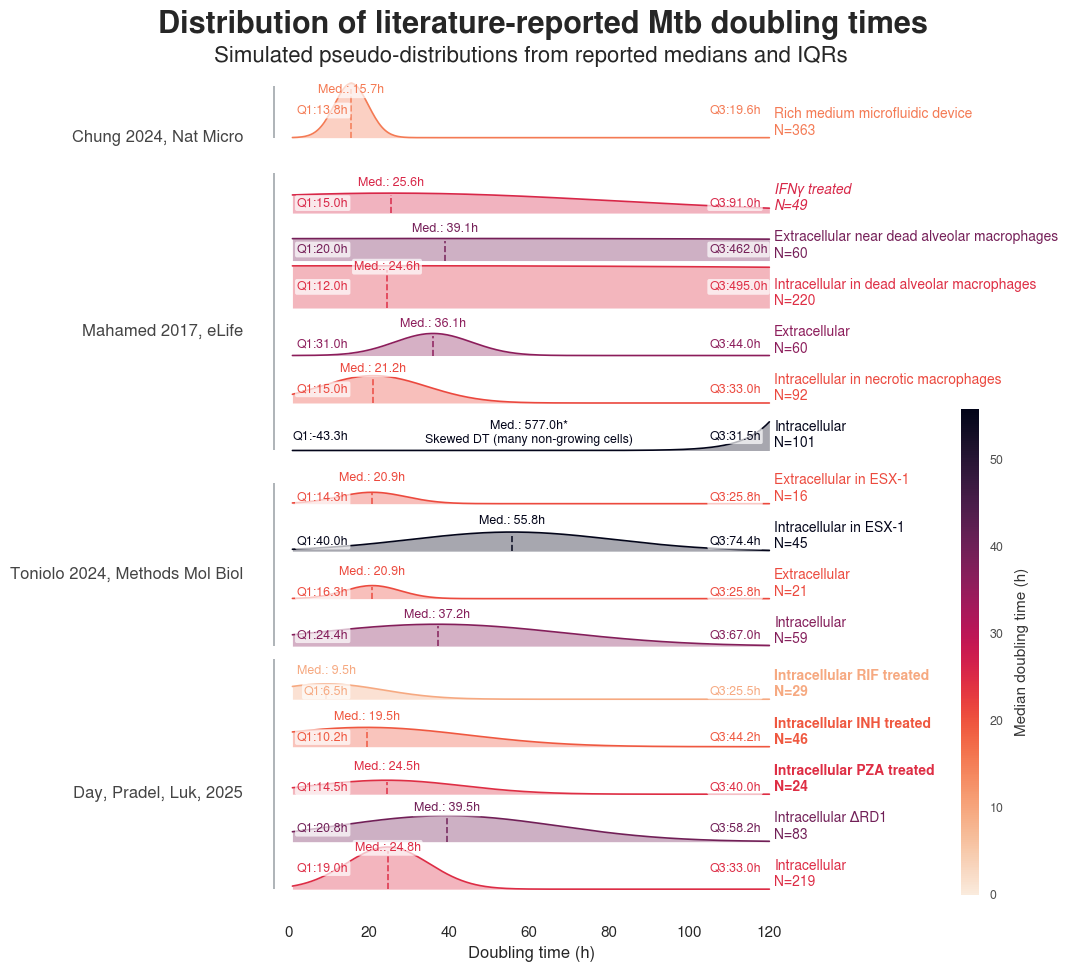

In [76]:
fig_h = max(10, 0.85 * len(ids_order))
fig, ax = plt.subplots(figsize=(11, fig_h))

for (idv, cult), d in plot_df.groupby(["ID", "Culture details"], sort=False):
    base  = base_for[(idv, cult)]
    ypeak = d["y"].max() * height_scale * gain
    yplot = base + d["y"] * height_scale * gain

    # median-driven color (fallback to per-culture palette if missing)
    col = colors_by_pair.get((idv, cult), colors.get(cult, (0.4, 0.4, 0.4)))

    ax.fill_between(d["x"], base, yplot, color=col, alpha=0.35, linewidth=0)
    ax.plot(d["x"], yplot, color=col, lw=1.2)

    # dashed median
    med = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "Median (h)"]
    if not med.empty and med.values[0] > 0:
        ax.vlines(med.values[0], base, base + 0.9 * ypeak,
                  colors=col, linestyles="--", lw=1.2, alpha=0.9)

    # inline N label
    N_series = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "N"]
    N_text = f"N={int(N_series.values[0])}" if (not N_series.empty and pd.notna(N_series.values[0])) else "N=NA"
    if 'IFN' in cult:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col,fontstyle='italic')
    elif 'treated' in cult:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col, fontweight='bold')    
    else:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col)
    # quartile tags
    row = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult),
                 ["Q1 (h)", "Median (h)", "Q3 (h)"]]
    if not row.empty:
        q1, medx, q3 = row.iloc[0]["Q1 (h)"], row.iloc[0]["Median (h)"], row.iloc[0]["Q3 (h)"]
        y_anchor = base + 0.5 * ypeak
        x_left, x_right = 15, 105

        if pd.notna(q1):
            ax.text(x_left, y_anchor, f"Q1:{q1:.1f}h",
                    ha="right", va="center", fontsize=9, color=col,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                    zorder=5)

        if pd.notna(medx):
            if xmin <= medx <= xmax:
                ax.text(medx, y_anchor + 15, f"Med.: {medx:.1f}h",
                        ha="center", va="bottom", fontsize=9, color=col,
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                        zorder=5)
            else:
                ax.text(xmax/2, y_anchor - 10, f"Med.: {medx:.1f}h*\nSkewed DT (many non-growing cells)",
                        ha="center", va="bottom", fontsize=9, color=col,
                        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                        zorder=5)

        if pd.notna(q3):
            ax.text(x_right, y_anchor, f"Q3:{q3:.1f}h",
                    ha="left", va="center", fontsize=9, color=col,
                    bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.7),
                    zorder=5)

# vertical group lines
span = {}
for idv in ids_order:
    bases = [base_for[(idv, c)] for c in id_specs[idv]["cults"]]
    y_low = min(bases)
    ypeak_max = peaks.loc[peaks["ID"] == idv, "ypeak"].max()
    y_high = max(bases) + 0.95 * ypeak_max
    span[idv] = (y_low, y_high)

xpad  = 0.03 * (xmax - xmin)
xline = xmin - xpad
for idv in ids_order:
    y0, y1 = span[idv]
    ax.vlines(xline, y0, y1, colors="#9aa0a6", linestyles="-", lw=1.4, alpha=0.8)

# axes + labels
ax.set_xlim(xmin - 2 * xpad, xmax * 1.07)
y_allmin = min(v[0] for v in span.values())
y_allmax = max(v[1] for v in span.values())
ypad = 0.03 * (y_allmax - y_allmin)
ax.set_ylim(y_allmin - ypad, y_allmax + ypad)
ax.margins(y=0)
ax.set_yticks([]); ax.set_ylabel("")
plt.subplots_adjust(left=0.32, right=0.92)

from matplotlib.transforms import blended_transform_factory
bt = blended_transform_factory(ax.transAxes, ax.transData)
for idv in ids_order:
    ax.text(-0.03, y_center[idv], idv, transform=bt,
            ha="right", va="center", fontsize=12, color="#444", clip_on=False)

ax.set_xlabel("Doubling time (h)")
sns.despine(left=True, bottom=True, offset=10)

# titles
fig.suptitle("Distribution of literature-reported Mtb doubling times",
             fontsize=22, fontweight="bold", y=0.97)
ax.set_title("Simulated pseudo-distributions from reported medians and IQRs",
             fontsize=16, fontweight="normal", pad=0)

# Create the colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

# Example: move colorbar to the right but slightly lower and thinner
cbar = fig.colorbar(sm, ax=ax,
                    orientation='vertical',
                    fraction=0.025,      # width of colorbar
                    pad=0.22,            # distance from main plot
                    aspect=27,           # elongation
                    shrink=1,          # shorten relative to axes height
                    anchor=(2.5, 0.05))   # move up/down (0 bottom, 1 top)

# --- aesthetics ---
cbar.outline.set_visible(False)                 # remove frame
cbar.ax.tick_params(width=0, length=4,          # tick line width/length
                    labelsize=9,                # tick label font
                    colors='0.3')               # grey ticks
cbar.set_label("Median doubling time (h)",
               fontsize=11, color='0.2',
               labelpad=8,)

# optionally choose a different locator for ticks
from matplotlib.ticker import MaxNLocator
cbar.locator = MaxNLocator(nbins=6)
cbar.update_ticks()

plt.tight_layout()
# plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/mtb_dt_dist/psuedo_dist_w_atbs.pdf', bbox_inches='tight', dpi=314)
plt.show()


### Dark mode

In [115]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')
old_cmap = plt.cm.get_cmap('PiYG')

# Adjust 'start' and 'stop' to taste (0.0 to 1.0).
start = 0.0  # Increase this to cut more of the "bottom" end
stop  = 0.8  # Decrease this to cut more of the "top" end

new_colors = old_cmap(np.linspace(start, stop, 256))
cmap = mcolors.LinearSegmentedColormap.from_list("cropped_cmap", new_colors)

/tmp/ipykernel_4016669/1405639301.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = plt.cm.get_cmap('PiYG')


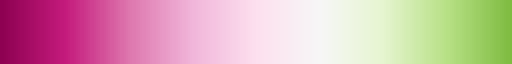

In [119]:
cmap

/tmp/ipykernel_4016669/4230882778.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = plt.cm.get_cmap('PiYG_r')


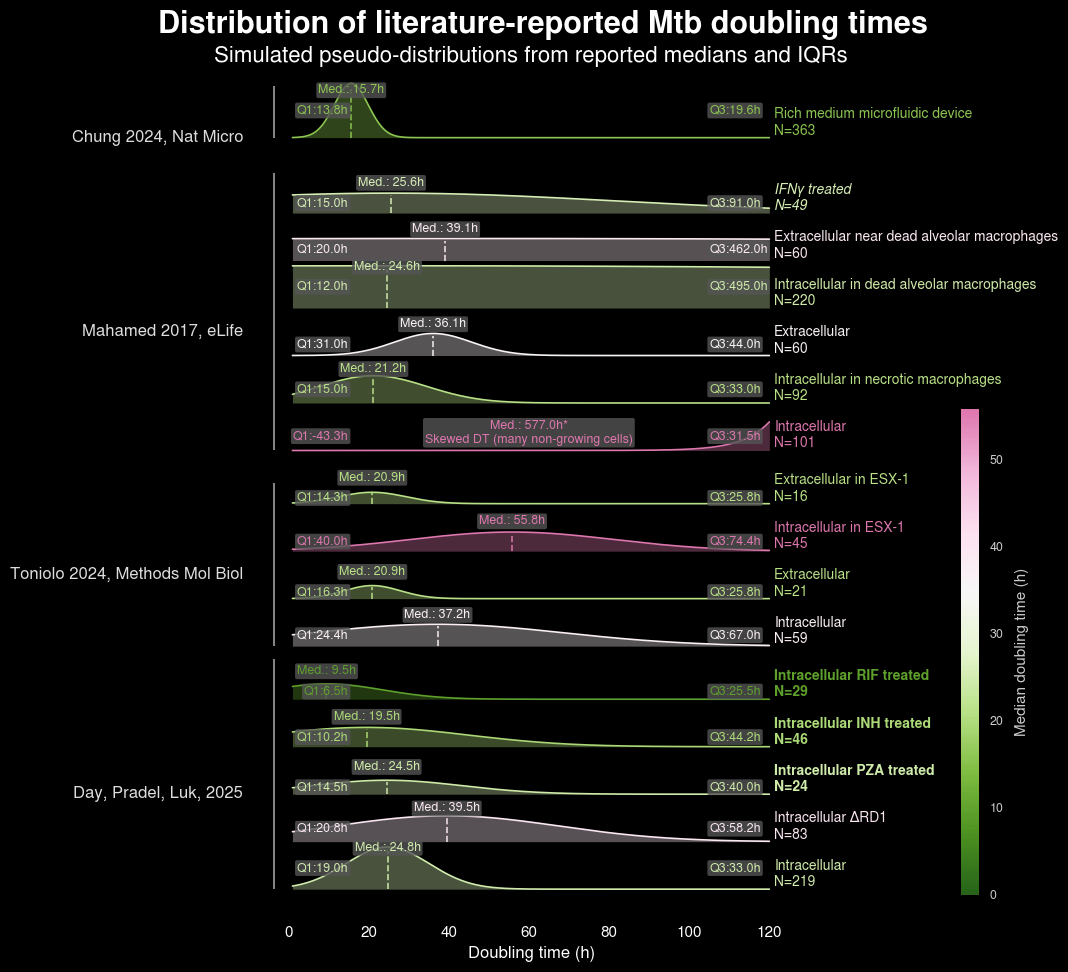

In [124]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
import pandas as pd

# 1. Set Dark Mode
plt.style.use('dark_background')

# 2. Create the Custom Cropped Colormap (PiYG)
# We crop it to remove the darkest end if necessary, or just to limit the range.
# Based on your snippet: 0.0 to 0.8
old_cmap = plt.cm.get_cmap('PiYG_r')
start = 0.0 
stop  = 0.8 
new_colors = old_cmap(np.linspace(start, stop, 256))
cmap = mcolors.LinearSegmentedColormap.from_list("cropped_cmap", new_colors)

# 3. Setup Figure
fig_h = max(10, 0.85 * len(ids_order))
fig, ax = plt.subplots(figsize=(11, fig_h))

# 4. Main Plotting Loop
for (idv, cult), d in plot_df.groupby(["ID", "Culture details"], sort=False):
    base  = base_for[(idv, cult)]
    ypeak = d["y"].max() * height_scale * gain
    yplot = base + d["y"] * height_scale * gain

    # --- COLOR SELECTION LOGIC (Fixed to remove Plasma) ---
    # Retrieve the median for this specific pair
    med_val_series = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "Median (h)"]
    
    # Calculate color dynamically using the NEW cmap and existing norm
    if not med_val_series.empty and pd.notna(med_val_series.values[0]):
        median_val = med_val_series.values[0]
        col = cmap(norm(median_val)) # Uses the new PiYG map
    else:
        # Fallback: Use the end of the colormap (lightest/brightest part) 
        # instead of gray, so it is visible on black.
        col = cmap(1.0) 

    # Plot Distribution
    ax.fill_between(d["x"], base, yplot, color=col, alpha=0.35, linewidth=0)
    ax.plot(d["x"], yplot, color=col, lw=1.2)

    # Plot Dashed Median Line
    if not med_val_series.empty and med_val_series.values[0] > 0:
        ax.vlines(med_val_series.values[0], base, base + 0.9 * ypeak,
                  colors=col, linestyles="--", lw=1.2, alpha=0.9)

    # Inline N label
    N_series = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "N"]
    N_text = f"N={int(N_series.values[0])}" if (not N_series.empty and pd.notna(N_series.values[0])) else "N=NA"
    
    # Text styling based on culture type
    if 'IFN' in cult:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col, fontstyle='italic')
    elif 'treated' in cult:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col, fontweight='bold')    
    else:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col)

    # Quartile Tags
    row = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult),
                 ["Q1 (h)", "Median (h)", "Q3 (h)"]]
    if not row.empty:
        q1, medx, q3 = row.iloc[0]["Q1 (h)"], row.iloc[0]["Median (h)"], row.iloc[0]["Q3 (h)"]
        y_anchor = base + 0.5 * ypeak
        x_left, x_right = 15, 105

        # Box style for dark mode: Light grey background (#E0E0E0)
        bbox_style = dict(boxstyle="round,pad=0.15", fc="#555555", ec="none", alpha=0.8)

        if pd.notna(q1):
            ax.text(x_left, y_anchor, f"Q1:{q1:.1f}h",
                    ha="right", va="center", fontsize=9, color=col,
                    bbox=bbox_style, zorder=5)

        if pd.notna(medx):
            if xmin <= medx <= xmax:
                ax.text(medx, y_anchor + 15, f"Med.: {medx:.1f}h",
                        ha="center", va="bottom", fontsize=9, color=col,
                        bbox=bbox_style, zorder=5)
            else:
                ax.text(xmax/2, y_anchor - 10, f"Med.: {medx:.1f}h*\nSkewed DT (many non-growing cells)",
                        ha="center", va="bottom", fontsize=9, color=col,
                        bbox=bbox_style, zorder=5)

        if pd.notna(q3):
            ax.text(x_right, y_anchor, f"Q3:{q3:.1f}h",
                    ha="left", va="center", fontsize=9, color=col,
                    bbox=bbox_style, zorder=5)

# 5. Vertical Group Lines
span = {}
for idv in ids_order:
    bases = [base_for[(idv, c)] for c in id_specs[idv]["cults"]]
    y_low = min(bases)
    ypeak_max = peaks.loc[peaks["ID"] == idv, "ypeak"].max()
    y_high = max(bases) + 0.95 * ypeak_max
    span[idv] = (y_low, y_high)

xpad  = 0.03 * (xmax - xmin)
xline = xmin - xpad
for idv in ids_order:
    y0, y1 = span[idv]
    # Divider lines: Light grey for visibility
    ax.vlines(xline, y0, y1, colors="#aaaaaa", linestyles="-", lw=1.4, alpha=0.8)

# 6. Axes + Labels
ax.set_xlim(xmin - 2 * xpad, xmax * 1.07)
y_allmin = min(v[0] for v in span.values())
y_allmax = max(v[1] for v in span.values())
ypad = 0.03 * (y_allmax - y_allmin)
ax.set_ylim(y_allmin - ypad, y_allmax + ypad)
ax.margins(y=0)
ax.set_yticks([]); ax.set_ylabel("")
plt.subplots_adjust(left=0.32, right=0.92)

# ID Labels on left
from matplotlib.transforms import blended_transform_factory
bt = blended_transform_factory(ax.transAxes, ax.transData)
for idv in ids_order:
    # Text: Very light grey (#ddd)
    ax.text(-0.03, y_center[idv], idv, transform=bt,
            ha="right", va="center", fontsize=12, color="#ddd", clip_on=False)

ax.set_xlabel("Doubling time (h)")
sns.despine(left=True, bottom=True, offset=10)

# Titles
fig.suptitle("Distribution of literature-reported Mtb doubling times",
             fontsize=22, fontweight="bold", y=0.97, color='white')
ax.set_title("Simulated pseudo-distributions from reported medians and IQRs",
             fontsize=16, fontweight="normal", pad=0, color='white')

# 7. Colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax,
                    orientation='vertical',
                    fraction=0.025,
                    pad=0.22,
                    aspect=27,
                    shrink=1,
                    anchor=(2.5, 0.05))

# Colorbar aesthetics for Dark Mode
cbar.outline.set_visible(False)
cbar.ax.tick_params(width=0, length=4, labelsize=9, colors='0.8') # Light ticks
cbar.set_label("Median doubling time (h)", fontsize=11, color='0.8', labelpad=8)
cbar.locator = MaxNLocator(nbins=6)
cbar.update_ticks()

plt.tight_layout()
# Save with facecolor included to ensure black background persists
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/psuedo_dist_w_atbs_dark.pdf', 
            bbox_inches='tight', dpi=314, facecolor=fig.get_facecolor())
plt.show()

/tmp/ipykernel_4016669/4029113802.py:13: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  old_cmap = plt.cm.get_cmap('PiYG_r')


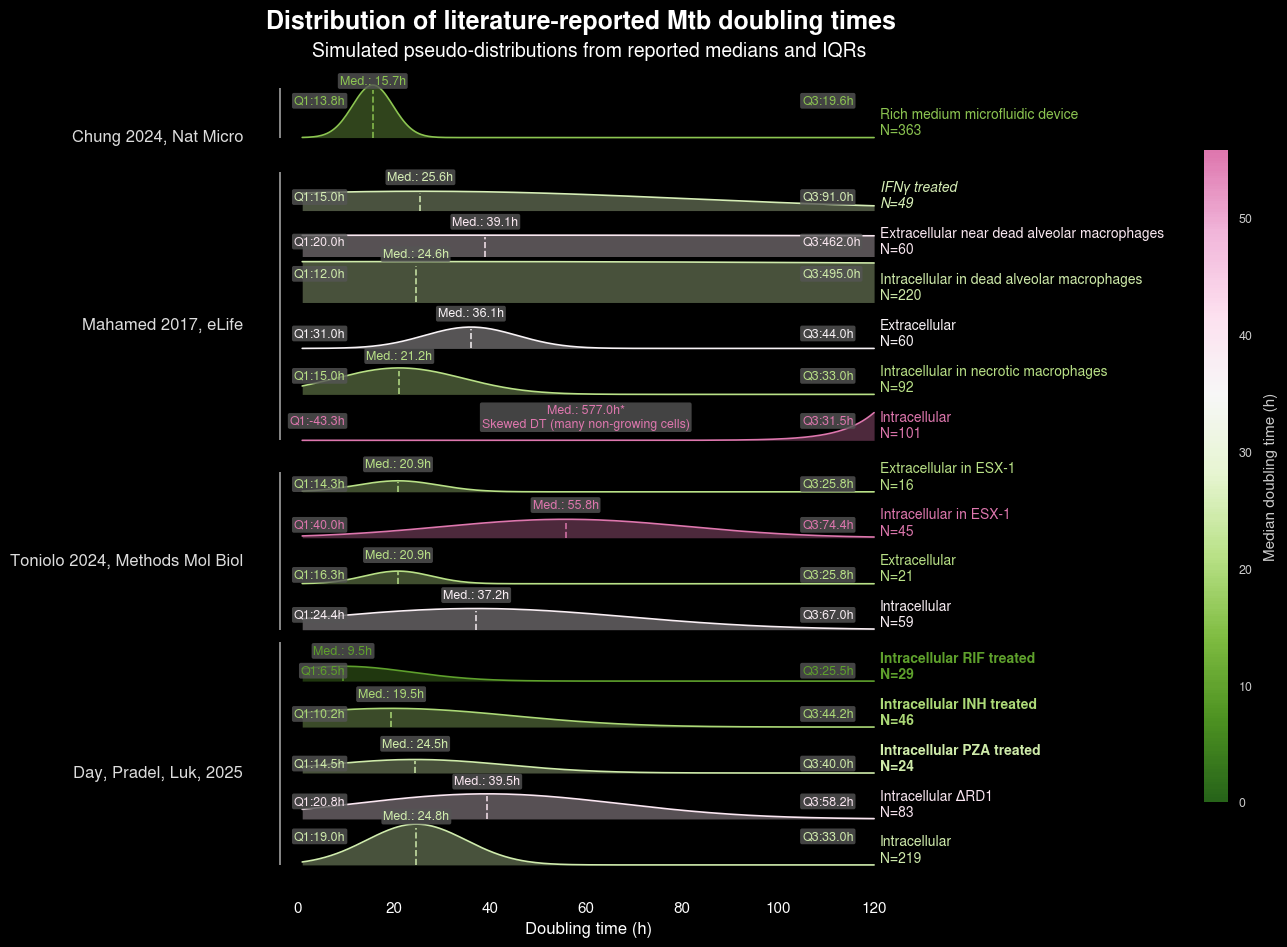

In [145]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import seaborn as sns
import pandas as pd

# 1. Set Dark Mode
plt.style.use('dark_background')

# 2. Create the Custom Cropped Colormap (PiYG)
# We crop it to remove the darkest end if necessary, or just to limit the range.
# Based on your snippet: 0.0 to 0.8
old_cmap = plt.cm.get_cmap('PiYG_r')
start = 0.0 
stop  = 0.8 
new_colors = old_cmap(np.linspace(start, stop, 256))
cmap = mcolors.LinearSegmentedColormap.from_list("cropped_cmap", new_colors)

# Standard Keynote/PowerPoint Widescreen ratio is 16:9
aspect_ratio = 12 / 9

# Set a fixed width (13 inches is usually good for slides with standard font sizes)
fig_width = 13 
fig_height = fig_width / aspect_ratio

# Create the figure with these fixed dimensions
fig, ax = plt.subplots(figsize=(fig_width, fig_height))

# 4. Main Plotting Loop
for (idv, cult), d in plot_df.groupby(["ID", "Culture details"], sort=False):
    base  = base_for[(idv, cult)]
    ypeak = d["y"].max() * height_scale * gain
    yplot = base + d["y"] * height_scale * gain

    # --- COLOR SELECTION LOGIC (Fixed to remove Plasma) ---
    # Retrieve the median for this specific pair
    med_val_series = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "Median (h)"]
    
    # Calculate color dynamically using the NEW cmap and existing norm
    if not med_val_series.empty and pd.notna(med_val_series.values[0]):
        median_val = med_val_series.values[0]
        col = cmap(norm(median_val)) # Uses the new PiYG map
    else:
        # Fallback: Use the end of the colormap (lightest/brightest part) 
        # instead of gray, so it is visible on black.
        col = cmap(1.0) 

    # Plot Distribution
    ax.fill_between(d["x"], base, yplot, color=col, alpha=0.35, linewidth=0)
    ax.plot(d["x"], yplot, color=col, lw=1.2)

    # Plot Dashed Median Line
    if not med_val_series.empty and med_val_series.values[0] > 0:
        ax.vlines(med_val_series.values[0], base, base + 0.9 * ypeak,
                  colors=col, linestyles="--", lw=1.2, alpha=0.9)

    # Inline N label
    N_series = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult), "N"]
    N_text = f"N={int(N_series.values[0])}" if (not N_series.empty and pd.notna(N_series.values[0])) else "N=NA"
    
    # Text styling based on culture type
    if 'IFN' in cult:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col, fontstyle='italic')
    elif 'treated' in cult:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col, fontweight='bold')    
    else:
        ax.text(xmax * 1.01, base, cult + f'\n{N_text}',
            ha="left", va="bottom", fontsize=10, color=col)

    # Quartile Tags
    row = df.loc[(df["ID"] == idv) & (df["Culture details"] == cult),
                 ["Q1 (h)", "Median (h)", "Q3 (h)"]]
    if not row.empty:
        q1, medx, q3 = row.iloc[0]["Q1 (h)"], row.iloc[0]["Median (h)"], row.iloc[0]["Q3 (h)"]
        y_anchor = base + 0.7 * ypeak
        x_left, x_right = 10, 105

        # Box style for dark mode: Light grey background (#E0E0E0)
        bbox_style = dict(boxstyle="round,pad=0.15", fc="#555555", ec="none", alpha=0.8)

        if pd.notna(q1):
            ax.text(x_left, y_anchor, f"Q1:{q1:.1f}h",
                    ha="right", va="center", fontsize=9, color=col,
                    bbox=bbox_style, zorder=5)

        if pd.notna(medx):
            if xmin <= medx <= xmax:
                ax.text(medx, y_anchor + 15, f"Med.: {medx:.1f}h",
                        ha="center", va="bottom", fontsize=9, color=col,
                        bbox=bbox_style, zorder=5)
            else:
                ax.text(xmax/2, y_anchor - 10, f"Med.: {medx:.1f}h*\nSkewed DT (many non-growing cells)",
                        ha="center", va="bottom", fontsize=9, color=col,
                        bbox=bbox_style, zorder=5)

        if pd.notna(q3):
            ax.text(x_right, y_anchor, f"Q3:{q3:.1f}h",
                    ha="left", va="center", fontsize=9, color=col,
                    bbox=bbox_style, zorder=5)

# 5. Vertical Group Lines
span = {}
for idv in ids_order:
    bases = [base_for[(idv, c)] for c in id_specs[idv]["cults"]]
    y_low = min(bases)
    ypeak_max = peaks.loc[peaks["ID"] == idv, "ypeak"].max()
    y_high = max(bases) + 0.95 * ypeak_max
    span[idv] = (y_low, y_high)

xpad  = 0.03 * (xmax - xmin)
xline = xmin - xpad
for idv in ids_order:
    y0, y1 = span[idv]
    # Divider lines: Light grey for visibility
    ax.vlines(xline, y0, y1, colors="#aaaaaa", linestyles="-", lw=1.4, alpha=0.8)

# 6. Axes + Labels
ax.set_xlim(xmin - 2 * xpad, xmax * 1.07)
y_allmin = min(v[0] for v in span.values())
y_allmax = max(v[1] for v in span.values())
ypad = 0.03 * (y_allmax - y_allmin)
ax.set_ylim(y_allmin - ypad, y_allmax + ypad)
ax.margins(y=0)
ax.set_yticks([]); ax.set_ylabel("")
plt.subplots_adjust(left=0.32, right=0.92)

# ID Labels on left
from matplotlib.transforms import blended_transform_factory
bt = blended_transform_factory(ax.transAxes, ax.transData)
for idv in ids_order:
    # Text: Very light grey (#ddd)
    ax.text(-0.03, y_center[idv], idv, transform=bt,
            ha="right", va="center", fontsize=12, color="#ddd", clip_on=False)

ax.set_xlabel("Doubling time (h)")
sns.despine(left=True, bottom=True, offset=10)

# Titles
fig.suptitle("Distribution of literature-reported Mtb doubling times",
             fontsize=18, fontweight="bold", y=0.97, color='white', x=0.45)
ax.set_title("Simulated pseudo-distributions from reported medians and IQRs",
             fontsize=14, fontweight="normal", color='white')

# 7. Colorbar
sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])

cbar = fig.colorbar(sm, ax=ax,
                    orientation='vertical',
                    fraction=0.025,
                    pad=0.3,
                    aspect=27,
                    shrink=1,
                    anchor=(2.5, 0.5))

# Colorbar aesthetics for Dark Mode
cbar.outline.set_visible(False)
cbar.ax.tick_params(width=0, length=4, labelsize=9, colors='0.8') # Light ticks
cbar.set_label("Median doubling time (h)", fontsize=11, color='0.8', labelpad=8)
cbar.locator = MaxNLocator(nbins=6)
cbar.update_ticks()

plt.tight_layout()
# Save with facecolor included to ensure black background persists
plt.savefig('/mnt/OPERA3/Nathan/data/macrohet/macrohet_results/mtb_dt_dist/psuedo_dist_w_atbs_dark_for_slides.pdf', 
            bbox_inches='tight', dpi=314, facecolor=fig.get_facecolor())
plt.show()